# Macro Regime Strategy Stress Test

Sector-rotation performance, data checks, shifted-feature diagnostics, historical regimes, and drawdowns.

**Saved historical analysis:** outputs were retained from repository revision `49abbc19`; they have not been rerun. The original run includes 82 quarterly observations, a coverage warning, and a warning that stale features do not degrade performance enough. Its generated report files and configuration baseline are not bundled with this notebook.

**These outputs predate a look-ahead fix:** the training window included the next quarter’s return through the label at the decision date. Training now excludes that label, and stock eligibility filters no longer bypass empty selections. These saved performance numbers do not evaluate the corrected implementation; see the folder guide for current pipeline checks.

The notebook retains its original metric definitions, including a CAGR/volatility Sharpe proxy. These differ from the current shared backtesting conventions.

To run a new experiment, read reports from `src/playground/macro_regime/reports/`, or call the pipeline if no results exist. See the [folder guide](../README.md) for dependencies, the configuration baseline, and data-quality prerequisites.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
def safe_display_df(df, subset_pct=None, subset_float=None):
    """Displays DataFrame with styling if jinja2 is present, otherwise displays plain."""
    try:
        styler = df.style
        if subset_pct:
            styler = styler.format("{:.2%}", subset=subset_pct)
        if subset_float:
            styler = styler.format("{:.2f}", subset=subset_float)
        display(styler)
    except (ImportError, AttributeError, ValueError) as e:
        print(f"Warning: Could not apply styling ({e}). Displaying raw data.")
        display(df)


## 1. Load or Build Backtest Results

In [3]:
from pathlib import Path
import sys

REPO_ROOT = next(
    parent for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "src" / "utils" / "ranking.py").is_file()
)

sys.path.insert(0, str(REPO_ROOT))
base_dir = REPO_ROOT / "src" / "playground" / "macro_regime"
reports_dir = base_dir / "reports"
results_path = reports_dir / "backtest_results.csv"

if results_path.exists():
    df = pd.read_csv(results_path, parse_dates=["Date"], index_col="Date")
    print(f"Loaded {results_path}")
else:
    print("backtest_results.csv not found. Running backtest pipeline using local data if available...")
    from src.playground.macro_regime.backtest import run_backtest_pipeline

    df, _ = run_backtest_pipeline(output_dir=reports_dir)
    print(f"Generated {results_path}")

# Ensure index and columns are usable downstream
df.index = pd.to_datetime(df.index, errors="coerce")
df = df[~df.index.isna()].sort_index()
df["PortRet"] = pd.to_numeric(df["PortRet"], errors="coerce")
df["SPYRet"] = pd.to_numeric(df["SPYRet"], errors="coerce")

# Recalculate equity curves for safety
df["PortEq"] = (1 + df["PortRet"].fillna(0.0)).cumprod()
df["SPYEq"] = (1 + df["SPYRet"].fillna(0.0)).cumprod()

print(f"Rows loaded: {len(df)}")
df.head()


Loaded /home/lucas_albanese/PMC/LongShort_EquityFund/macro_regime/reports/backtest_results.csv
Rows loaded: 82


,PortRet,SPYRet,PredSectors,PredSectorNames,RealTopSectors,TopStocksInPredSectors,PortEq,SPYEq,AlphaEq
Date,,,,,,,,,
2005-09-30,-0.001000,0.036782,NaN,NaN,"Energy,Information Technology,Industrials",0,0.999000,1.036782,-0.037782
2005-12-31,0.049438,0.017311,"Consumer Discretionary,Real Estate,Materials","Consumer Discretionary,Real Estate,Materials","Financials,Materials,Industrials",2,1.048388,1.054731,-0.006342
2006-03-31,0.068767,0.046874,"Energy,Information Technology,Consumer Discret...","Energy,Information Technology,Consumer Discret...","Real Estate,Industrials,Information Technology",5,1.120482,1.104170,0.016312
2006-06-30,-0.000629,-0.015308,"Information Technology,Consumer Staples,Utilities","Information Technology,Consumer Staples,Utilities","Communication Services,Utilities,Consumer Staples",3,1.119777,1.087267,0.032510
2006-09-30,0.093877,0.054113,"Real Estate,Information Technology,Consumer Di...","Real Estate,Information Technology,Consumer Di...","Real Estate,Communication Services,Information...",8,1.224898,1.146103,0.078796


## 1b. Current Data & Reliability Status

In [4]:
checks_path = reports_dir / "data_checks_results.csv"
diag_path = reports_dir / "diagnostics_results.csv"
rel_path = reports_dir / "reliability_report.txt"
quality_path = base_dir / "data" / "quality_report.csv"

if checks_path.exists():
    checks_df = pd.read_csv(checks_path)
    print("Data checks:")
    display(checks_df)
    warns = checks_df.loc[checks_df["status"] == "WARN", ["check", "detail"]]
    fails = checks_df.loc[checks_df["status"] == "FAIL", ["check", "detail"]]
    print(f"PASS={int((checks_df['status']=='PASS').sum())} WARN={len(warns)} FAIL={len(fails)}")
    if not warns.empty:
        print("Warnings:")
        display(warns)
    if not fails.empty:
        print("Fails:")
        display(fails)
else:
    print("No data_checks_results.csv found")

if diag_path.exists():
    diag_df = pd.read_csv(diag_path)
    print("Diagnostics:")
    display(diag_df)
else:
    print("No diagnostics_results.csv found")

if rel_path.exists():
    print("Reliability report:")
    print(rel_path.read_text(encoding="utf-8"))
else:
    print("No reliability_report.txt found")

if quality_path.exists():
    quality_df = pd.read_csv(quality_path)
    print("Quality report sample:")
    display(quality_df.head(20))
else:
    print("No quality_report.csv found")


Data checks:


,check,status,detail
0,schema_date_column,PASS,Date column found.
1,schema_spy_column,PASS,SPY column found.
2,date_parse,PASS,All Date rows parsed.
3,date_duplicates,PASS,No duplicate Date rows.
4,date_monotonic,PASS,Dates are increasing.
5,nonpositive_prices,PASS,No non-positive prices detected.
6,date_span,PASS,Rows=315 span_days=9556 from 1999-12-31 to 202...
7,return_outliers,PASS,"Outlier count within threshold: 67 (|r|>80%, m..."
8,overall_data_coverage,WARN,Average non-null coverage over active windows:...
9,constituent_price_overlap,PASS,Overlap symbols=501/503 (99.60%)


PASS=11 WARN=1 FAIL=0
Warnings:


,check,detail
8,overall_data_coverage,Average non-null coverage over active windows:...


Diagnostics:


,Test,NQuarters,AnnRet,AnnVol,Sharpe,MaxDD,HitRateVsSPY,AvgAlphaQ
0,Strategy_Main,82.0,0.192757,0.164458,1.172073,-0.252021,0.682927,0.015622
1,EqualWeight_AllStocks,103.0,0.488376,1.287802,0.379233,-0.428827,0.660194,0.081804
2,RandomSector_Baseline,NaN,0.145862,NaN,0.781025,NaN,NaN,0.005148
3,StaleFeatures_ShiftPlus1Q,81.0,0.159778,0.148516,1.075828,-0.225299,0.580247,0.008413
4,LeakedFeatures_ShiftMinus1Q,81.0,0.400104,0.147729,2.708357,-0.167569,0.950617,0.058313
5,ShuffledLabels_Sanity,82.0,0.137857,0.190346,0.724242,-0.432464,0.609756,0.003383


Reliability report:
Reliability Score Report
Score: 66.0/100
Target: 65.0
Status: PASS
Drivers:
- Data checks WARN count: 1
- Coverage warning present.
- Stale-feature test does not degrade enough.
Action: acceptable to present with disclosed assumptions.
Quality report sample:


,Metric,Ticker,Date,Value,Note
0,Coverage,ALL,Final_Raw,0.7075,Raw Active Window
1,Coverage,ALL,Final_Effective,0.9642,Effective Active Window
2,ExtremeMove,ADBE,2000-02-29,0.8524,real_move
3,ExtremeMove,NTAP,2000-02-29,0.8804,real_move
4,ExtremeMove,CBE,2000-03-31,6.4500,real_move
5,ExtremeMove,CIEN,2000-03-31,0.9219,real_move
6,ExtremeMove,BIIB,2000-06-30,0.8384,real_move
7,ExtremeMove,ISRG,2000-07-31,1.0000,real_move
8,ExtremeMove,TIE,2000-09-30,0.8196,real_move
9,ExtremeMove,NTAP,2001-10-31,0.9559,real_move


## 2. Global Performance Metrics

In [5]:
def calculate_metrics(series, freq=4):  # Quarterly freq = 4
    if series.empty:
        return {}

    total_ret = (1 + series).prod() - 1
    n_years = len(series) / freq if len(series) > 0 else 0
    cagr = (1 + total_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan

    ann_vol = series.std() * np.sqrt(freq)

    # Risk-adjusted returns
    sharpe = cagr / ann_vol if ann_vol != 0 else 0
    risk_adj_ret = total_ret / ann_vol if ann_vol != 0 else 0

    downside = series[series < 0]
    downside_vol = downside.std() * np.sqrt(freq)
    sortino = cagr / downside_vol if downside_vol != 0 else 0

    cum = (1 + series).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    max_dd = dd.min()

    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    return {
        "TotalReturn": total_ret,
        "CAGR": cagr,
        "Vol": ann_vol,
        "Sharpe": sharpe,
        "RiskAdjRet": risk_adj_ret,
        "Sortino": sortino,
        "MaxDD": max_dd,
        "Calmar": calmar,
    }

port_metrics = calculate_metrics(df["PortRet"])
spy_metrics = calculate_metrics(df["SPYRet"])

metrics_df = pd.DataFrame([port_metrics, spy_metrics], index=["Portfolio", "SPY"])

print(
    f"Total Return -> Portfolio: {port_metrics.get('TotalReturn', np.nan):.2%} | "
    f"SPY: {spy_metrics.get('TotalReturn', np.nan):.2%}"
)

safe_display_df(
    metrics_df,
    subset_pct=["TotalReturn", "CAGR", "Vol", "MaxDD"],
    subset_float=["Sharpe", "RiskAdjRet", "Sortino", "Calmar"],
)

Total Return -> Portfolio: 2765.65% | SPY: 736.80%


,TotalReturn,CAGR,Vol,Sharpe,RiskAdjRet,Sortino,MaxDD,Calmar
Portfolio,2765.65%,17.78%,16.45%,1.08,168.17,1.52,-25.20%,0.71
SPY,736.80%,10.92%,15.84%,0.69,46.51,0.87,-45.96%,0.24


## 3. Visualization Dashboard

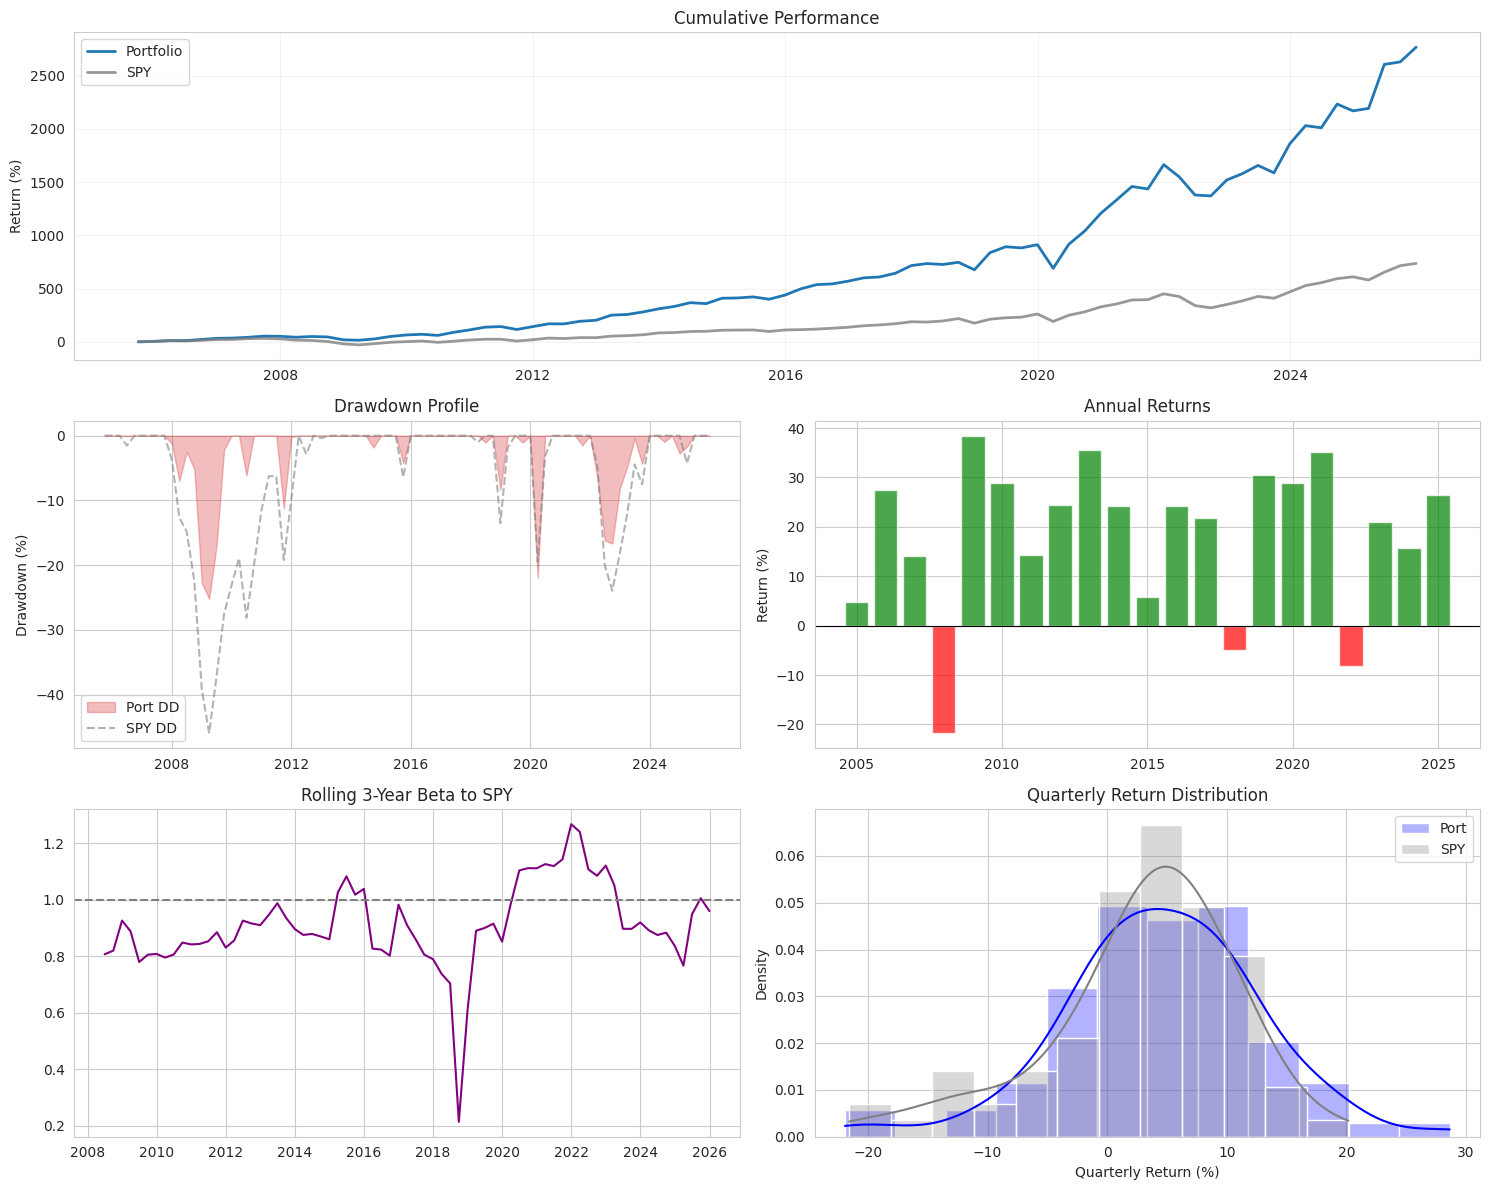

In [6]:
fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(3, 2)

# 1. Cumulative Return % (Top Full Width)
ax1 = fig.add_subplot(gs[0, :])
port_cum_pct = (df["PortEq"] - 1.0) * 100
spy_cum_pct = (df["SPYEq"] - 1.0) * 100
ax1.plot(df.index, port_cum_pct, label="Portfolio", linewidth=2, color="#1f77b4")
ax1.plot(df.index, spy_cum_pct, label="SPY", linewidth=2, color="#7f7f7f", alpha=0.8)
ax1.set_title("Cumulative Performance")
ax1.set_ylabel("Return (%)")
ax1.legend()
ax1.grid(True, alpha=0.25)

# 2. Drawdowns
ax2 = fig.add_subplot(gs[1, 0])
dd_port = (df["PortEq"] / df["PortEq"].cummax()) - 1
dd_spy = (df["SPYEq"] / df["SPYEq"].cummax()) - 1
ax2.fill_between(df.index, dd_port * 100, 0, color="#d62728", alpha=0.3, label="Port DD")
ax2.plot(df.index, dd_spy * 100, color="gray", alpha=0.6, linestyle="--", label="SPY DD")
ax2.set_title("Drawdown Profile")
ax2.set_ylabel("Drawdown (%)")
ax2.legend()

# 3. Annual Returns
ax3 = fig.add_subplot(gs[1, 1])
annual_ret = df["PortRet"].resample("YE").apply(lambda x: (1 + x).prod() - 1)
colors = ["green" if x > 0 else "red" for x in annual_ret]
ax3.bar(annual_ret.index.year, annual_ret * 100, color=colors, alpha=0.7)
ax3.axhline(0, color="black", linewidth=0.8)
ax3.set_title("Annual Returns")
ax3.set_ylabel("Return (%)")

# 4. Rolling Beta to SPY (3-year)
ax4 = fig.add_subplot(gs[2, 0])
window = 12  # 3 years on quarterly data
cov = df["PortRet"].rolling(window).cov(df["SPYRet"])
var = df["SPYRet"].rolling(window).var()
beta = cov / var
ax4.plot(beta, color="purple")
ax4.axhline(1, linestyle="--", color="gray")
ax4.set_title("Rolling 3-Year Beta to SPY")

# 5. Return Distribution
ax5 = fig.add_subplot(gs[2, 1])
sns.histplot(df["PortRet"] * 100, kde=True, ax=ax5, color="blue", alpha=0.3, label="Port", stat="density")
sns.histplot(df["SPYRet"] * 100, kde=True, ax=ax5, color="gray", alpha=0.3, label="SPY", stat="density")
ax5.set_title("Quarterly Return Distribution")
ax5.set_xlabel("Quarterly Return (%)")
ax5.legend()

plt.tight_layout()
plt.show()

## 4. Regime Analysis

We define specific historical periods to stress-test the strategy.

In [7]:
regimes = {
    "GFC": ("2007-10-01", "2009-03-31"),
    "Bull Market": ("2010-01-01", "2019-12-31"),
    "Covid 2020": ("2020-01-01", "2020-12-31"),
    "inflation 2022": ("2022-01-01", "2022-12-31"),
    "AI Rally": ("2023-01-01", "2026-12-31")
}

regime_results = []

for name, (start, end) in regimes.items():
    sub = df.loc[start:end]
    if sub.empty:
        continue

    m_port = calculate_metrics(sub["PortRet"])
    m_spy = calculate_metrics(sub["SPYRet"])

    row = {"Regime": name}
    for k, v in m_port.items():
        row[f"Port_{k}"] = v
    for k, v in m_spy.items():
        row[f"SPY_{k}"] = v
    row["Alpha_Total"] = (1 + sub["PortRet"]).prod() - (1 + sub["SPYRet"]).prod()

    regime_results.append(row)

regime_df = pd.DataFrame(regime_results).set_index("Regime")

cols = [
    "Port_TotalReturn", "SPY_TotalReturn",
    "Port_CAGR", "SPY_CAGR",
    "Port_MaxDD", "SPY_MaxDD",
    "Port_Sharpe", "SPY_Sharpe",
    "Port_Sortino", "SPY_Sortino",
    "Alpha_Total"
]
cols = [c for c in cols if c in regime_df.columns]

print("Regime Performance Table:")
safe_display_df(
    regime_df[cols],
    subset_pct=[c for c in cols if "TotalReturn" in c or "CAGR" in c or "MaxDD" in c or "Alpha" in c],
    subset_float=[c for c in cols if "Sharpe" in c or "Sortino" in c],
)

Regime Performance Table:


,Port_TotalReturn,SPY_TotalReturn,Port_CAGR,SPY_CAGR,Port_MaxDD,SPY_MaxDD,Port_Sharpe,SPY_Sharpe,Port_Sortino,SPY_Sortino,Alpha_Total
Regime,,,,,,,,,,,
GFC,-25.20%,-45.96%,-17.60%,-33.66%,-24.29%,-43.90%,-1.13,-2.47,-1.25,-2.47,20.76%
Bull Market,513.01%,252.76%,19.88%,13.44%,-11.23%,-13.82%,1.48,1.05,2.52,1.15,260.26%
Covid 2020,28.95%,18.33%,28.95%,18.33%,0.00%,0.00%,0.67,0.53,nan,nan,10.61%
inflation 2022,-8.17%,-18.18%,-8.17%,-18.18%,-10.82%,-20.25%,-0.46,-0.94,-0.83,-1.39,10.00%
AI Rally,76.93%,85.50%,20.95%,22.87%,-3.94%,-4.27%,1.48,2.19,6.91,15.51,-8.57%


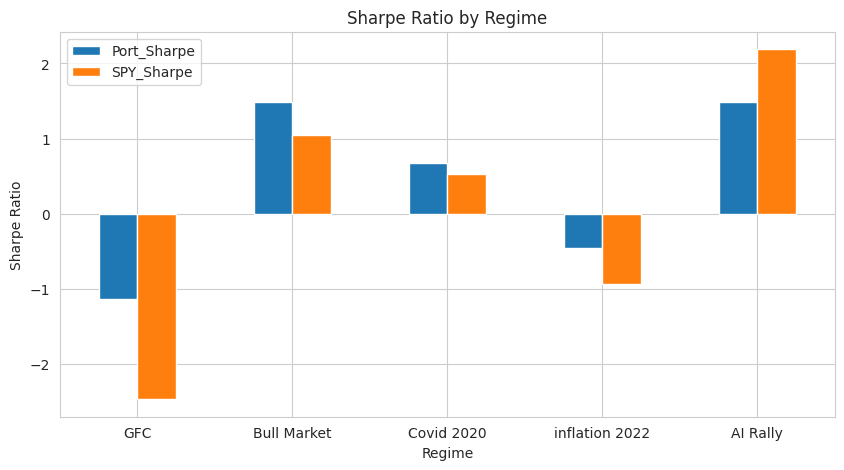

In [8]:
# Visualizing Regime Sharpes
if not regime_df.empty:
    regime_df[["Port_Sharpe", "SPY_Sharpe"]].plot(kind="bar", figsize=(10, 5), title="Sharpe Ratio by Regime")
    plt.ylabel("Sharpe Ratio")
    plt.xticks(rotation=0)
    plt.show()

## 5. Drawdown Table
Top 5 deepest drawdowns.

In [9]:
def get_drawdown_table(series):
    # Calculate drawdown series
    cum = (1 + series).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    
    # Identify drawdown periods (simple approach)
    is_dd = dd < 0
    # ... complex dd logic omitted for simplicity, showing annual worsts instead or just sorting monthly entries
    return dd.sort_values().head(5)

print("Top 5 Worst Quarterly Drawdowns (Point-in-time):")
print(get_drawdown_table(df["PortRet"])*100)

Top 5 Worst Quarterly Drawdowns (Point-in-time):
Date
2009-03-31   -25.202148
2008-12-31   -22.753236
2020-03-31   -21.926447
2009-06-30   -16.978396
2022-09-30   -16.645261
Name: PortRet, dtype: float64
